In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r'D:\Naveed\Educational\hospital-readmission-predictor\data\raw\\'
PROCESSED = r'D:\Naveed\Educational\hospital-readmission-predictor\data\processed\\'
REPORTS = r'D:\Naveed\Educational\hospital-readmission-predictor\reports\\'

In [4]:
df = pd.read_csv(DATA_PATH + 'diabetic_data.csv')

df = df.replace('NaN', np.nan)


df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'])

# Drop duplicates by patient
df = df.drop_duplicates(subset='patient_nbr', keep='first')

print(df.shape)

(71518, 47)


In [5]:
# Binary: readmitted <30 days = 1, else = 0
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted_binary'].value_counts())
print(f"Readmission rate: {df['readmitted_binary'].mean()*100:.1f}%")

readmitted_binary
0    65225
1     6293
Name: count, dtype: int64
Readmission rate: 8.8%


In [6]:
features = [
    'age', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses',
    'insulin', 'diabetesMed', 'change'
]

df_model = df[features + ['readmitted_binary']].copy()

# Encode categoricals
cat_cols = ['age', 'insulin', 'diabetesMed', 'change']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model = df_model.dropna()
print(df_model.shape)

(71518, 13)


In [7]:
X = df_model.drop('readmitted_binary', axis=1)
y = df_model['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (57214, 12)
Test: (14304, 12)


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'pred': y_pred, 'auc': auc}
    print(f"{name} → AUC: {auc:.4f}")

Logistic Regression → AUC: 0.6133
Random Forest → AUC: 0.5732
Gradient Boosting → AUC: 0.6210


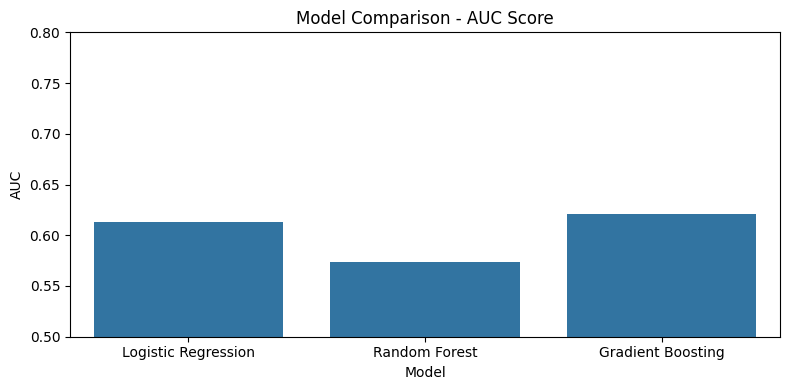

                 Model       AUC
0  Logistic Regression  0.613255
1        Random Forest  0.573241
2    Gradient Boosting  0.620965


In [9]:
result_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC': [v['auc'] for v in results.values()]
})

plt.figure(figsize=(8,4))
sns.barplot(data=result_df, x='Model', y='AUC')
plt.title('Model Comparison - AUC Score')
plt.ylim(0.5, 0.8)
plt.tight_layout()
plt.savefig(REPORTS + 'model_comparison.png')
plt.show()
print(result_df)

In [10]:
best_model = results['Gradient Boosting']['model']

with open(PROCESSED + 'model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature names
with open(PROCESSED + 'features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model saved ✅")

Model saved ✅


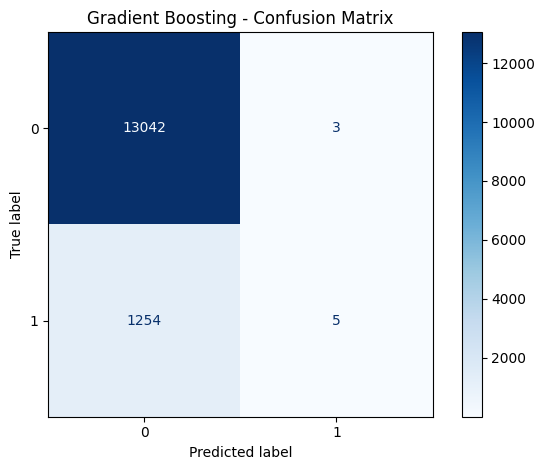

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     13045
           1       0.62      0.00      0.01      1259

    accuracy                           0.91     14304
   macro avg       0.77      0.50      0.48     14304
weighted avg       0.89      0.91      0.87     14304



In [11]:
cm = confusion_matrix(y_test, results['Gradient Boosting']['pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Gradient Boosting - Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORTS + 'confusion_matrix.png')
plt.show()

print(classification_report(y_test, results['Gradient Boosting']['pred']))